<a href="https://colab.research.google.com/github/SAO-P/Pytorch-Exercise/blob/main/PyTorch3_1_nn_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

autograd

In [22]:
import torch

In [23]:
x=torch.tensor([1.],requires_grad=True)
print(x)

tensor([1.], requires_grad=True)


In [24]:
x=torch.tensor([1.])
print(x)
print(x.requires_grad)

tensor([1.])
False


In [25]:
x.requires_grad=True
print(x)
print(x.requires_grad)

tensor([1.], requires_grad=True)
True


기본은 False로 된다. 맨위에서 처럼 만들때 True로 하던가 나중에 바꿔주던가

In [26]:
x=torch.tensor([1.],requires_grad=True)
y=x**2
print(y)
print(x.grad)  #아무것도 안나올것

tensor([1.], grad_fn=<PowBackward0>)
None


Pow = Power => 거듭제곱

In [27]:
y.backward()   #미분하는함수
print(x.grad)  #y=x**2를 미분한 2x에 1을 대입한 gradient 값

tensor([2.])


In [28]:
x=torch.tensor([1.],requires_grad=True)
y=x**2
print(y)
#y.retain_grad() #이걸로 y.grad도 볼 수 있다.

z=3*y
print(z)

z.backward()
print(x.grad)
# print(y.grad) #이런 중간거는 안됨

tensor([1.], grad_fn=<PowBackward0>)
tensor([3.], grad_fn=<MulBackward0>)
tensor([6.])


Mul = Multiply => 곱

In [29]:
x=torch.tensor([1.],requires_grad=True)
y=torch.tensor([1.],requires_grad=True)
z=2*x**2 + y**2
print(z)  #AddBackward0 가 붙어있음
z.backward()
print(x.grad)
print(y.grad)

tensor([3.], grad_fn=<AddBackward0>)
tensor([4.])
tensor([2.])


In [30]:
x=torch.tensor([1.,2.,3.,],requires_grad=True)
y=torch.sum(x**2)  #x1**2 + x2**2 + x3**2
y.backward()

print(y)
print(x.grad)

tensor(14., grad_fn=<SumBackward0>)
tensor([2., 4., 6.])


In [31]:
x=torch.tensor([1.],requires_grad=True)
x.requires_grad=False
# transter learning 에서 필요
y=x**2
print(y)
#y.backward() #error!

tensor([1.])


In [32]:
x=torch.tensor([2.],requires_grad=True)
x2=x.detach() # detach는 requires_grad=False 인 새 텐서를 만드는 것

print(x)
y=x**2
print(y)

print(x2)
y2=x2**2
print(y2)


tensor([2.], requires_grad=True)
tensor([4.], grad_fn=<PowBackward0>)
tensor([2.])
tensor([4.])


x로 만든 것을 상수로 사용하고 싶을때, y.requires_grad=False 이런식으로는 안된다. 상수로서 카피해서 쓰기위해 detach를 사용

In [33]:
#많이 쓰이는 torch.no_grad
x=torch.tensor([1.],requires_grad=True)
# chain rule을 위해 계속 grad_fn을 업데이트 하는데, grad_fn을 잠시 계산하지 않고 싶을 때 사용
#모델 테스트 등에서는 불필요하게 메모리를 쓰지 않아도 되기 떄문.

with torch.no_grad():
    y = x**2
    print(x.requires_grad) #감싸도 여전히 requires_grad는 True!
    print(y) #with 내부에서 계산되는 것은 grad_fn이 붙지 않음

print(x.requires_grad)
# y.backward() #error!
y=x**2
print(y)


True
tensor([1.])
True
tensor([1.], grad_fn=<PowBackward0>)


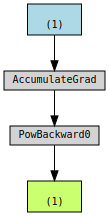

In [34]:
!pip install torchviz
from torchviz import make_dot
x=torch.tensor([1.],requires_grad=True)
#make_dot(x)
make_dot(x**2)


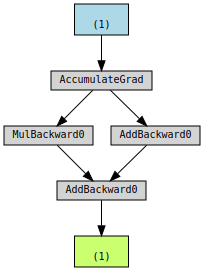

In [35]:
y=2*x
z=3+x
r=y+z
make_dot(r)

AccumulateGrad는 x로 여러가지 계산을 한것을 더해주기위해서 존재 (거꾸로 생각할때)